In [1]:
import os
os.chdir('../')

In [8]:
!ls samplings/GMDiT/1.4/200/Euler/1000/train_traj_0

0.pt	200.pt	301.pt	402.pt	503.pt	604.pt	705.pt	806.pt	907.pt
100.pt	201.pt	302.pt	403.pt	504.pt	605.pt	706.pt	807.pt	908.pt
101.pt	202.pt	303.pt	404.pt	505.pt	606.pt	707.pt	808.pt	909.pt
102.pt	203.pt	304.pt	405.pt	506.pt	607.pt	708.pt	809.pt	90.pt
103.pt	204.pt	305.pt	406.pt	507.pt	608.pt	709.pt	80.pt	910.pt
104.pt	205.pt	306.pt	407.pt	508.pt	609.pt	70.pt	810.pt	911.pt
105.pt	206.pt	307.pt	408.pt	509.pt	60.pt	710.pt	811.pt	912.pt
106.pt	207.pt	308.pt	409.pt	50.pt	610.pt	711.pt	812.pt	913.pt
107.pt	208.pt	309.pt	40.pt	510.pt	611.pt	712.pt	813.pt	914.pt
108.pt	209.pt	30.pt	410.pt	511.pt	612.pt	713.pt	814.pt	915.pt
109.pt	20.pt	310.pt	411.pt	512.pt	613.pt	714.pt	815.pt	916.pt
10.pt	210.pt	311.pt	412.pt	513.pt	614.pt	715.pt	816.pt	917.pt
110.pt	211.pt	312.pt	413.pt	514.pt	615.pt	716.pt	817.pt	918.pt
111.pt	212.pt	313.pt	414.pt	515.pt	616.pt	717.pt	818.pt	919.pt
112.pt	213.pt	314.pt	415.pt	516.pt	617.pt	718.pt	819.pt	91.pt
113.pt	214.pt	315.pt	416.pt	517.pt	618.pt	719.pt	81.pt	920.pt
114.p

In [11]:
import torch
weights = torch.load('samplings/GMDiT/1.4/200/Euler/1000/train_traj_0/0.pt')
weights.keys()

dict_keys(['cond', 'sample', 'noise', 'traj', 'timesteps', 'alphas', 'sigmas'])

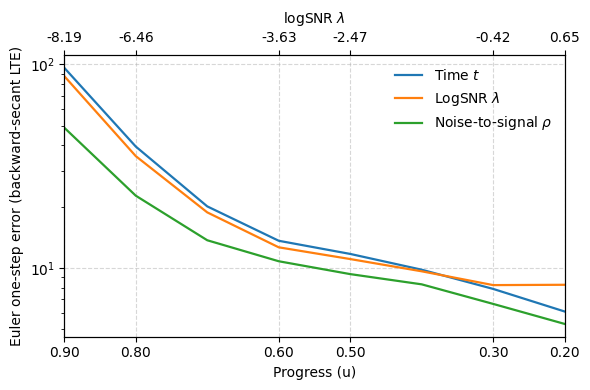

In [30]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

import os
import torch
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Config
# =========================
base        = 'samplings/DiT/1.5/200/Euler/100/paper_0'
N           = 100         # 0.pt ~ 99.pt
stride      = 20
pred_index  = 0           # 0: data-pred, 1: noise-pred (여기서는 RHS 대용으로 preds 사용)
device      = 'cpu'
dtype       = torch.double

# =========================
# LTE (two-point backward slope) helper
# =========================
@torch.no_grad()
def lte_euler_two_point(axis_s: torch.Tensor, Y: torch.Tensor):
    """
    axis_s: [S]      도메인 축 (t, λ, ρ), 비균일 가능
    Y:      [S, D]   시계열 (여기서는 preds를 평탄화해 사용)
    return: [S-2]    i=1..S-2 에 대해 Euler 예측 vs 실제 다음값의 L2 오차
    """
    s = axis_s.to(dtype).flatten()
    S, D = Y.shape
    # Δs_i = s_{i+1} - s_i
    ds = (s[2:] - s[1:-1])                      # [S-2]
    # backward slope at i: (Y_i - Y_{i-1}) / (s_i - s_{i-1})
    denom = (s[1:-1] - s[:-2]).unsqueeze(1)     # [S-2,1]
    slope = (Y[1:-1] - Y[:-2]) / denom          # [S-2, D]

    # Euler predict next: y_hat_{i+1} = Y_i + Δs_i * slope_i
    y_hat_next = Y[1:-1] + ds.unsqueeze(1) * slope   # [S-2, D]

    # LTE surrogate: || y_hat_{i+1} - Y_{i+1} ||_2
    err = torch.linalg.norm(y_hat_next - Y[2:], dim=1)  # [S-2]
    return err

# =========================
# Load reference axes (0.pt)
# =========================
w0 = torch.load(f'{base}/0.pt', map_location=device)
S  = w0['preds'][::stride, pred_index].shape[0]

t      = w0['timesteps'][:-1:stride].to(dtype)
alpha  = w0['alphas'][:-1:stride].to(dtype)
sigma  = w0['sigmas'][:-1:stride].to(dtype)
lam    = torch.log((alpha**2)/(sigma**2))   # λ = log(α^2/σ^2)
rho    = sigma / alpha

# =========================
# Accumulate LTE curves for t, λ, ρ
# =========================
lte_t_sum = torch.zeros(S-2, dtype=dtype)
lte_l_sum = torch.zeros(S-2, dtype=dtype)
lte_r_sum = torch.zeros(S-2, dtype=dtype)

count = 0
with torch.no_grad():
    for i in range(N):
        pt_file = f'{base}/{i}.pt'
        if not os.path.exists(pt_file):
            continue
        w = torch.load(pt_file, map_location=device)

        # preds: [S, ...] -> [S, D]
        Y = w['preds'][::stride, pred_index].to(dtype).reshape(S, -1)

        lte_t_sum += lte_euler_two_point(t,   Y)
        lte_l_sum += lte_euler_two_point(lam, Y)
        lte_r_sum += lte_euler_two_point(rho, Y)
        count += 1

assert count > 0, "No .pt files found."
lte_t = (lte_t_sum / count).clamp_min(1e-18)
lte_l = (lte_l_sum / count).clamp_min(1e-18)
lte_r = (lte_r_sum / count).clamp_min(1e-18)

# 진행률 좌표(스텝 중앙 인덱스: i=1..S-2)
x_prog = torch.linspace(0, 1, S-2)

# 눈금: 스텝 중앙의 t, λ 값
t_mid   = t[1:-1]
lam_mid = lam[1:-1]

# =========================
# Plot (log-scale)
# =========================
n_ticks  = 6
idx_plot = torch.linspace(0, S-3, steps=n_ticks).round().long()  # 0..S-3 for S-2 points
xpos     = (idx_plot.double() / (S-3)).tolist()

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x_prog.numpy(), lte_t.numpy(), label='Time $t$',                linewidth=1.6)
ax.plot(x_prog.numpy(), lte_l.numpy(), label='LogSNR $\\lambda$',       linewidth=1.6)
ax.plot(x_prog.numpy(), lte_r.numpy(), label='Noise-to-signal $\\rho$', linewidth=1.6)

ax.set_yscale('log')
ax.set_xlim(0, 1)
ax.set_ylabel('Euler one-step error (backward-secant LTE)')
ax.set_xlabel('Progress (u)')
ax.grid(True, which='major', linestyle='--', alpha=0.5)
ax.legend(frameon=False)

# bottom ticks: t(mid index)
ax.set_xticks(xpos)
ax.set_xticklabels([f'{t_mid[i].item():.2f}' for i in idx_plot])

# top ticks: λ(mid index)
ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())
ax_top.set_xticks(xpos)
ax_top.set_xticklabels([f'{lam_mid[i].item():.2f}' for i in idx_plot])
ax_top.set_xlabel('logSNR $\\lambda$', labelpad=6)

fig.tight_layout()
plt.show()


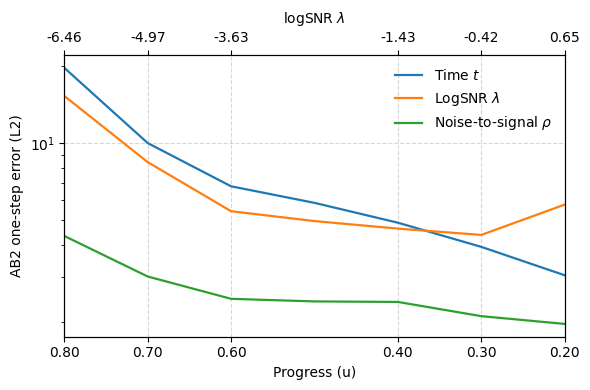

In [33]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

import os
import torch
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Config
# =========================
base        = 'samplings/DiT/1.5/200/Euler/100/paper_0'
N           = 100         # 0.pt ~ 99.pt
stride      = 20
pred_index  = 0           # 0: data-pred, 1: noise-pred (여기서는 상태 시계열로 사용)
device      = 'cpu'
dtype       = torch.double

# =========================
# LTE (2-step Adams–Bashforth, variable-step) helper
# =========================
@torch.no_grad()
def lte_ab2_two_point(axis_s: torch.Tensor, Y: torch.Tensor):
    """
    axis_s: [S]      도메인 축 (t, λ, ρ), 비균일 가능
    Y:      [S, D]   상태(또는 상태 대용) 시계열 (여기서는 preds를 평탄화해 사용)
    return: [S-3]    i=2..S-2 에 대한 AB2 예측 vs 실제 다음값의 L2 오차
    """
    s = axis_s.to(dtype).flatten()
    S, D = Y.shape

    # 구간 길이 h_i = s_i - s_{i-1},  i = 1..S-1
    h = s[1:] - s[:-1]                             # [S-1]

    # 기울기 근사 (secant): f_i ≈ (Y_i - Y_{i-1})/h_i
    f = (Y[1:] - Y[:-1]) / h.unsqueeze(1)          # [S-1, D]

    # 유효 인덱스 i = 2..S-2  (f_i와 f_{i-1}, h_i와 h_{i-1} 모두 필요)
    i_lo, i_hi = 2, S-2
    m = i_hi - i_lo + 1                            # = S-3
    if m <= 0:
        raise ValueError("Series too short for AB2 LTE (need S >= 4).")

    # 각 i에서 r = h_i / h_{i-1}
    h_i   = h[i_lo: i_hi+1]                        # [m]
    h_im1 = h[i_lo-1: i_hi]                        # [m]
    r     = h_i / h_im1                            # [m]

    # f_i, f_{i-1}
    f_i   = f[i_lo: i_hi+1, :]                     # [m, D]
    f_im1 = f[i_lo-1: i_hi,   :]                   # [m, D]

    # AB2 predictor: y_hat_{i+1} = y_i + h_i * [ (1 + r/2) f_i - (r/2) f_{i-1} ]
    coeff_i   = (1.0 + 0.5 * r).unsqueeze(1)       # [m,1]
    coeff_im1 = (0.5 * r).unsqueeze(1)             # [m,1]
    y_i       = Y[i_lo: i_hi+1, :]                 # [m, D]
    y_hat_np1 = y_i + h_i.unsqueeze(1) * (coeff_i * f_i - coeff_im1 * f_im1)

    # 실제 y_{i+1}
    y_np1 = Y[i_lo+1: i_hi+2, :]                   # [m, D]

    # LTE: || y_hat_{i+1} - y_{i+1} ||_2
    err = torch.linalg.norm(y_hat_np1 - y_np1, dim=1)  # [m]
    return err, torch.arange(i_lo, i_hi+1)             # 에러와 기준 인덱스(i)

# =========================
# Load reference axes (0.pt)
# =========================
w0 = torch.load(f'{base}/0.pt', map_location=device)
S  = w0['preds'][::stride, pred_index].shape[0]

t      = w0['timesteps'][:-1:stride].to(dtype)
alpha  = w0['alphas'][:-1:stride].to(dtype)
sigma  = w0['sigmas'][:-1:stride].to(dtype)
lam    = torch.log((alpha**2)/(sigma**2))   # λ = log(α^2/σ^2)
rho    = sigma / alpha

# =========================
# Accumulate AB2-LTE curves for t, λ, ρ
# =========================
# 길이는 S-3가 됨 (i=2..S-2)
lte_t_sum = torch.zeros(S-3, dtype=dtype)
lte_l_sum = torch.zeros(S-3, dtype=dtype)
lte_r_sum = torch.zeros(S-3, dtype=dtype)

count = 0
with torch.no_grad():
    for i in range(N):
        pt_file = f'{base}/{i}.pt'
        if not os.path.exists(pt_file):
            continue
        w = torch.load(pt_file, map_location=device)

        # preds: [S, ...] -> [S, D]
        Y = w['preds'][::stride, pred_index].to(dtype).reshape(S, -1)

        err_t, idx_t = lte_ab2_two_point(t,   Y)
        err_l, idx_l = lte_ab2_two_point(lam, Y)
        err_r, idx_r = lte_ab2_two_point(rho, Y)
        # (세 도메인은 같은 길이/인덱스여야 함)
        lte_t_sum += err_t
        lte_l_sum += err_l
        lte_r_sum += err_r
        count += 1

assert count > 0, "No .pt files found."
lte_t = (lte_t_sum / count).clamp_min(1e-18)
lte_l = (lte_l_sum / count).clamp_min(1e-18)
lte_r = (lte_r_sum / count).clamp_min(1e-18)

# 진행률 좌표 (i=2..S-2를 0~1로 선형 매핑)
S_eff  = S - 3
x_prog = torch.linspace(0, 1, S_eff)

# 눈금: 기준 인덱스 i에 해당하는 중앙 값(여기서는 i 시점 자체를 라벨로 사용)
t_idx = torch.arange(2, S-1)       # 길이 S-3
lam_idx = t_idx

# =========================
# Plot (log-scale)
# =========================
n_ticks  = 6
idx_plot = torch.linspace(0, S_eff-1, steps=n_ticks).round().long()
xpos     = (idx_plot.double() / (S_eff-1)).tolist()

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x_prog.numpy(), lte_t.numpy(), label='Time $t$',                linewidth=1.6)
ax.plot(x_prog.numpy(), lte_l.numpy(), label='LogSNR $\\lambda$',       linewidth=1.6)
ax.plot(x_prog.numpy(), lte_r.numpy(), label='Noise-to-signal $\\rho$', linewidth=1.6)

ax.set_yscale('log')
ax.set_xlim(0, 1)
ax.set_ylabel('AB2 one-step error (L2)')
ax.set_xlabel('Progress (u)')
ax.grid(True, which='major', linestyle='--', alpha=0.5)
ax.legend(frameon=False)

# bottom ticks: t at index i (가운데 시점의 실제 t값)
ax.set_xticks(xpos)
ax.set_xticklabels([f'{t[j.item()].item():.2f}' for j in (t_idx[idx_plot])])

# top ticks: λ at same indices
ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())
ax_top.set_xticks(xpos)
ax_top.set_xticklabels([f'{lam[j.item()].item():.2f}' for j in (lam_idx[idx_plot])])
ax_top.set_xlabel('logSNR $\\lambda$', labelpad=6)

fig.tight_layout()
plt.show()
